# exp_14 — GAT-GRU on IMD minimap (matched IMD vs ERA5 comparison)

**Track 1A.** Train the GAT-GRU architecture (same as exp_13) on a small, clean subset of *real* IMD
gauge stations, and compare it against the *same architecture trained on ERA5 reanalysis for the
identical stations and window*. This isolates the effect of **data source** (observation vs reanalysis),
which the exp_13-vs-IMD comparison in the original README could not do (it confounded data source,
feature count, station count and time window).

### Design decisions (locked with Risheek, 2026-05-29)
1. **Window-first selection.** IMD missingness from 1970 is ~74% and *block-structured* — every low-missing
   station still has whole-year gaps, and 2021 is 100% empty (would poison a temporal test split).
   Restricting to **2000–2020 first**, then picking the cleanest stations, yields a graph that is genuine
   on ~98% of days. (See `docs/track_1a_imd_minimap/` analysis.)
2. **Top-16 cleanest stations** (max missing 0.46%, 10 districts, 566×303 km spread).
3. **Three matched runs** in this notebook:
   - **Run 1 — IMD rain-only** (7 features: rain + 6 cyclic time).
   - **Run 2 — ERA5 rain-only**, *same 16 stations, same window* (7 features). ← the apples-to-apples control.
   - **Run 3 — ERA5 full** (12 features: 6 ERA5 vars + 6 time). Shows how much auxiliary variables add.
4. **exp_13 config kept identical** (in_channels aside) for a fair comparison. Overfitting handled by
   **best-val checkpoint** (already saved by `train_model`) plus **persistence + climatology baselines**
   as a skill floor. No model/util files are modified.

### Fixes vs exp_12/exp_13 baked in here
- **Scaler/split alignment** (`status.md` known issue #2): `scale_pivots` is called with `train_end` set to the
  actual 70%-split date, not the hard-coded `2015-12-31`.
- **No cosmetic prediction adjustment** (exp_12 cells 64+69 are *not* reproduced). Scatter uses raw preds.
- **Seed 42** set at the top (`plan.md` cross-cutting note 6).

### Reused code (read-only, unchanged)
`utils/data_utils/data_helper_utils.py` · `utils/data_utils/dataset_files/gnn_dataset.py` ·
`models/gat_gru.py` · `utils/train_utils.py` · `utils/metric_utils/metrics.py`.

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [5]:
# Repo root on path so `utils`, `models` import cleanly
sys.path.append('C:/Users/rishe/Dissertation')

In [6]:
# ===== Reused project code (UNCHANGED) =====
from utils.data_utils.data_helper_utils import (
    load_pivots, scale_pivots, get_lat_lon_aligned, build_edge_index_radius, temporal_split,
)
from utils.data_utils.dataset_files.gnn_dataset import (
    build_feature_tensor, build_time_features, add_time_features, SpatioTemporalDataset,
)
from models.gat_gru import GAT_GRU_Model
from utils.train_utils import train_model, evaluate
from utils.metric_utils.metrics import rmse, mae, bias, nrmse

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# ===== SEED (project convention) =====
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


In [8]:
# ====== CONFIG ======  (mirrors exp_13; in_channels is set per-run from the tensor)
EXP_ID = 'exp_14_gat_gru_imd_minimap'

# selection / window
WIN_START   = '2000-01-01'
WIN_END     = '2020-12-31'
N_STATIONS  = 16            # top-N cleanest within the window
GRAPH_THRESHOLD_KM = 150    # 100km isolates 1 northern node; 150km -> avg degree ~4.6, 0 isolated

# sequence / model (identical to exp_13)
SEQ_LEN    = 7
HORIZON    = 1
BATCH_SIZE = 32
HIDDEN_DIM = 64
HEADS      = 4
EPOCHS     = 30
LR         = 1e-3
CRITERION  = torch.nn.MSELoss()

# paths
DATA_DIR        = 'C:/Users/rishe/Dissertation/data'
ERA5_PIVOT_DIR  = f'{DATA_DIR}/era5_pivot_data/'
IMD_PARQUET     = f'{DATA_DIR}/preprocessed_rain_data.parquet'   # canonical IMD (3.96M rows, 0 NaN, full coords)

model_base   = f'C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}'
log_base     = f'C:/Users/rishe/Dissertation/experiments/logs/{EXP_ID}'
result_path  = f'C:/Users/rishe/Dissertation/experiments/results/{EXP_ID}'
os.makedirs(result_path, exist_ok=True)

RESULTS = {}   # filled as each run/baseline completes -> comparison table at the end
print("EXP_ID:", EXP_ID, "| results ->", result_path)

EXP_ID: exp_14_gat_gru_imd_minimap | results -> C:/Users/rishe/Dissertation/experiments/results/exp_14_gat_gru_imd_minimap


## Step 1 — Station selection (window-first)

Pivot the canonical IMD parquet to (date × station), restrict to **2000–2020**, keep only stations that
also exist in ERA5 (needed for the matched run), and take the **16 lowest-missingness** stations.

In [9]:
# ===== Load canonical IMD long-form, pivot, restrict to the window =====
imd_long = pd.read_parquet(IMD_PARQUET, columns=['station_id','date','rainfall','lat','lon','district'])
meta = imd_long.groupby('station_id')[['lat','lon','district']].first()

imd_piv_full = imd_long.pivot_table(index='date', columns='station_id', values='rainfall', aggfunc='first')
dates = pd.date_range(WIN_START, WIN_END, freq='D')          # complete daily calendar
imd_win = imd_piv_full.reindex(dates)                        # missing (station,date) -> NaN
imd_win.index.name = 'date'
print("IMD window pivot:", imd_win.shape, "| overall missing %.2f%%" % (imd_win.isna().mean().mean()*100))

IMD window pivot: (7671, 293) | overall missing 64.86%


In [10]:
# ===== ERA5 rain pivot (also the source for Runs 2 & 3); used here to intersect station names =====
era5_rain = pd.read_parquet(ERA5_PIVOT_DIR + 'rain_pivot.parquet')
era5_cols = set(era5_rain.columns)

missing_frac = imd_win.isna().mean().sort_values()
candidates   = [s for s in missing_frac.index if s in era5_cols]   # must be present in ERA5
selected     = candidates[:N_STATIONS]

print(f"Selected {len(selected)} stations | max missing_frac = {missing_frac[selected].max():.4f}")
print("All selected present in ERA5:", all(s in era5_cols for s in selected))

sel_df = meta.loc[selected].copy()
sel_df['missing_frac'] = missing_frac[selected].values
sel_df['district'] = sel_df['district'].str.strip()
sel_df = sel_df.reset_index()[['station_id','missing_frac','lat','lon','district']]
sel_df.to_csv(f'{result_path}/selected_stations.csv', index=False)

print("\nBounding box: lat %.2f..%.2f (%.0f km), lon %.2f..%.2f (%.0f km) | districts: %d"
      % (sel_df.lat.min(), sel_df.lat.max(), (sel_df.lat.max()-sel_df.lat.min())*111,
         sel_df.lon.min(), sel_df.lon.max(), (sel_df.lon.max()-sel_df.lon.min())*100,
         sel_df.district.nunique()))
display(sel_df)

Selected 16 stations | max missing_frac = 0.0046
All selected present in ERA5: True

Bounding box: lat 21.83..26.93 (566 km), lon 87.07..89.47 (240 km) | districts: 10


,station_id,missing_frac,lat,lon,district
0,SHANTI NIKETAN,0.000521,23.65,87.70,BIRBHUM
1,DUM DUM AERO,0.000521,22.65,88.45,24 PARGANAS N
2,MALDA,0.000652,25.03,88.13,MALDA
3,BANKURA,0.000913,23.22,87.07,BANKURA
4,DIGHA,0.000913,21.83,87.78,PURBA MEDINIPUR
5,NAGARKATA,0.001043,26.92,88.92,JALPAIGURI
6,MURTI,0.001173,26.85,88.83,JALPAIGURI
7,JALPAIGURI,0.001304,26.53,88.72,JALPAIGURI
8,HASIMARA,0.001434,26.67,89.33,ALIPURDUAR
9,CHENGMARI/DIANA,0.001564,26.93,89.00,JALPAIGURI


In [11]:
# ===== Validation gate: per-segment missingness (must be low; test must have real data) =====
T = len(dates)
t_end = int(0.70 * T)          # matches temporal_split (array variant)
v_end = int(0.85 * T)
train_end_date = dates[t_end - 1]
print("Split -> train<= %s | val<= %s | test %s..%s"
      % (train_end_date.date(), dates[v_end-1].date(), dates[v_end].date(), dates[-1].date()))

sub = imd_win[selected]
for name, seg in [('train', sub.iloc[:t_end]), ('val', sub.iloc[t_end:v_end]), ('test', sub.iloc[v_end:])]:
    print(f"  {name}: cell-missing {seg.isna().mean().mean()*100:4.1f}%  | all-present days {(~seg.isna()).all(axis=1).mean()*100:4.1f}%")
assert sub.iloc[v_end:].isna().mean().mean() < 0.10, "Test window too sparse — revisit selection."

Split -> train<= 2014-09-12 | val<= 2017-11-06 | test 2017-11-07..2020-12-31
  train: cell-missing  0.2%  | all-present days 98.2%
  val: cell-missing  0.1%  | all-present days 99.1%
  test: cell-missing  0.4%  | all-present days 95.1%


## Step 2 — Graph construction (shared across all three runs)

Build the radius graph once from the selected stations' coordinates. The **same edge_index** is valid for
all runs because the stations (and their physical locations) are identical across IMD and ERA5.

In [12]:
station_df = sel_df[['station_id','lat','lon']].copy()   # get_lat_lon_aligned expects station_id/lat/lon

# lat/lon aligned to the column order of `selected` (every run will index columns by `selected`)
lat, lon = get_lat_lon_aligned(imd_win[selected], station_df)

threshold = GRAPH_THRESHOLD_KM
edge_index = build_edge_index_radius(lat, lon, threshold_km=threshold)
avg_deg = edge_index.shape[1] / len(selected)

# ramp threshold up if the graph is too sparse (mirrors README fallback ladder)
for thr in (150, 200, 250):
    if avg_deg >= 1.5:
        break
    threshold = thr
    edge_index = build_edge_index_radius(lat, lon, threshold_km=threshold)
    avg_deg = edge_index.shape[1] / len(selected)

edge_index = edge_index.to(device)
isolated = len(selected) - len(torch.unique(edge_index[0]))
print(f"threshold = {threshold} km | edges = {edge_index.shape[1]} | avg degree = {avg_deg:.2f} | isolated nodes = {isolated}")

threshold = 150 km | edges = 74 | avg degree = 4.62 | isolated nodes = 0


## Step 3 — Reusable run + evaluation helper

`run_experiment` wires together the reused utils end to end: scale (with the **fixed `train_end`**) →
feature tensor → temporal split → datasets/loaders → `GAT_GRU_Model` → `train_model` → reload **best-val**
checkpoint → `evaluate` → back-scale → metrics → save CSVs + scatter. Returns the overall-metrics dict.

In [13]:
SEASONS = {'monsoon': [6, 7, 8, 9], 'non_monsoon': [1, 2, 3, 4, 5, 10, 11, 12]}

def _metrics(y_true, y_pred):
    return {'RMSE': rmse(y_true, y_pred), 'MAE': mae(y_true, y_pred),
            'Bias': bias(y_true, y_pred), 'NRMSE': nrmse(y_true, y_pred)}

def run_experiment(pivots_dict, use_latent, tag, title):
    # pivots_dict: {name: pivot_df} already restricted to `dates` rows and `selected` columns
    print(f"\n{'='*70}\n{title}  [tag={tag}, use_latent={use_latent}]\n{'='*70}")

    # 1) scale with the ACTUAL 70%-split date (fixes exp_12/13 leakage)
    scaled, scalers = scale_pivots(pivots_dict, train_end=str(train_end_date.date()))

    # 2) feature tensor (rain-only -> 1 dyn; full -> 6 dyn) + 6 cyclic time features
    X, feature_order = build_feature_tensor(scaled, use_latent=use_latent)
    X = add_time_features(X, build_time_features(dates))
    F = X.shape[-1]
    print("feature_order:", feature_order, "| X:", X.shape, "| in_channels =", F)

    # 3) temporal split (array variant, line 187) + datasets/loaders
    X_train, X_val, X_test = temporal_split(X, dates)
    train_loader = DataLoader(SpatioTemporalDataset(X_train, SEQ_LEN, HORIZON), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(SpatioTemporalDataset(X_val,   SEQ_LEN, HORIZON), batch_size=BATCH_SIZE)
    test_loader  = DataLoader(SpatioTemporalDataset(X_test,  SEQ_LEN, HORIZON), batch_size=BATCH_SIZE)
    print("windows train/val/test:", len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset))

    # 4) model + train (best-val checkpoint saved as {exp_name}_best.pt)
    exp_name = f"{EXP_ID}_{tag}"
    save_dir, log_dir = f"{model_base}/{tag}", f"{log_base}/{tag}"
    model = GAT_GRU_Model(in_channels=F, hidden_dim=HIDDEN_DIM, heads=HEADS)
    train_model(train_loader, val_loader, model, edge_index, device,
                epochs=EPOCHS, lr=LR, criterion=CRITERION,
                save_dir=save_dir, log_dir=log_dir, experiment_name=exp_name)

    # 5) reload BEST-val checkpoint (NOT the final epoch)
    best_state = torch.load(f"{save_dir}/{exp_name}_best.pt", map_location=device)
    model = GAT_GRU_Model(in_channels=F, hidden_dim=HIDDEN_DIM, heads=HEADS).to(device)
    model.load_state_dict(best_state); model.eval()

    # 6) evaluate (scaled) -> back-scale rain channel
    _, preds, targets = evaluate(model, test_loader, CRITERION, edge_index, device)
    mu, sigma = scalers['rain']
    preds_real, targets_real = preds * sigma + mu, targets * sigma + mu

    # 7) overall metrics (real space)
    overall = _metrics(targets_real.reshape(-1), preds_real.reshape(-1))
    overall.update({'tag': tag, 'data': title, 'in_channels': F, 'n_stations': len(selected)})
    print("OVERALL (real):", {k: round(v, 3) for k, v in overall.items() if isinstance(v, float)})

    # 8) seasonal metrics — align test dates to targets (sliding window)
    dates_test = dates[v_end:][SEQ_LEN + HORIZON - 1:]
    months = np.repeat(dates_test.month.values[:, None], preds.shape[1], axis=1).reshape(-1)
    seas_rows = []
    for sname, mons in SEASONS.items():
        m = np.isin(months, mons)
        if m.sum() == 0:
            continue
        r = _metrics(targets_real.reshape(-1)[m], preds_real.reshape(-1)[m]); r['season'] = sname
        seas_rows.append(r)
    seasonal_df = pd.DataFrame(seas_rows)
    seasonal_df.to_csv(f"{result_path}/{tag}_seasonal_metrics_real.csv", index=False)

    # 9) per-station metrics (real space)
    st_rows = []
    for i, sid in enumerate(selected):
        r = _metrics(targets_real[:, i], preds_real[:, i]); r['station_id'] = sid
        st_rows.append(r)
    station_df_metrics = pd.DataFrame(st_rows)[['station_id', 'RMSE', 'MAE', 'Bias', 'NRMSE']]
    station_df_metrics.to_csv(f"{result_path}/{tag}_station_metrics_real.csv", index=False)

    # 10) overall CSV + raw-pred scatter
    pd.DataFrame([overall]).to_csv(f"{result_path}/{tag}_overall_metrics.csv", index=False)
    plt.figure(figsize=(6, 6))
    tf, pf = targets_real.reshape(-1), preds_real.reshape(-1)
    plt.scatter(tf, pf, alpha=0.2, s=6)
    lim = max(tf.max(), pf.max())
    plt.plot([0, lim], [0, lim], 'r--')
    plt.xlabel("Observed rainfall (mm)"); plt.ylabel("Predicted rainfall (mm)")
    plt.title(f"{title} — observed vs predicted (raw)")
    plt.tight_layout(); plt.savefig(f"{result_path}/{tag}_observed_vs_predicted_scatter.png", dpi=120)
    plt.show()

    RESULTS[tag] = overall
    return overall

## Run 1 — IMD (rain-only, 7 features)

The headline result: can the GAT-GRU learn next-day rainfall from *real gauge observations* alone?


IMD rain-only (16 stations, 2000-2020)  [tag=imd_rain, use_latent=False]
feature_order: ['rain'] | X: (7671, 16, 7) | in_channels = 7
windows train/val/test: 5362 1144 1144
2026-05-29 18:35:03 | INFO | Starting GCN+GRU training
2026-05-29 18:35:03 | INFO | Device: cuda
2026-05-29 18:35:03 | INFO | Experiment Config:
2026-05-29 18:35:03 | INFO | LR: 0.001
2026-05-29 18:35:03 | INFO | Epochs: 30
2026-05-29 18:35:03 | INFO | Criterion: MSELoss()


Train:   0%|          | 0/168 [00:00<?, ?it/s]

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

2026-05-29 18:35:06 | INFO | Epoch 001 | Train: 0.811410 | Val: 0.828341
2026-05-29 18:35:06 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/imd_rain\epoch_1.pt
2026-05-29 18:35:06 | INFO | ✅ New best model saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/imd_rain\exp_14_gat_gru_imd_minimap_imd_rain_best.pt


Train:   0%|          | 0/168 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

2026-05-29 18:36:20 | INFO | Epoch 030 | Train: 0.672997 | Val: 0.864878
2026-05-29 18:36:20 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/imd_rain\epoch_30.pt
2026-05-29 18:36:20 | INFO | Training completed


C:\Users\rishe\AppData\Local\Temp\ipykernel_43164\1685478610.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_state = torch.load(f"{save_dir}/{exp_name}_best.pt", m

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

OVERALL (real): {'NRMSE': 2.717}


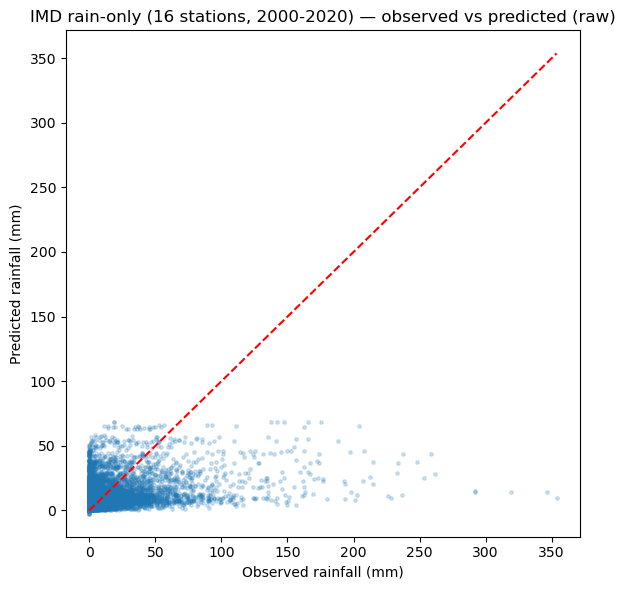

{'RMSE': 17.6012,
 'MAE': 7.6720347,
 'Bias': -0.00038078282,
 'NRMSE': 2.716782129373098,
 'tag': 'imd_rain',
 'data': 'IMD rain-only (16 stations, 2000-2020)',
 'in_channels': 7,
 'n_stations': 16}

In [14]:
imd_sub = imd_win[selected]                          # rows already = `dates`
run_experiment({'rain': imd_sub}, use_latent=False, tag='imd_rain',
               title='IMD rain-only (16 stations, 2000-2020)')

## Run 2 — ERA5 matched (rain-only, 7 features, same stations & window)

The apples-to-apples control. Everything is identical to Run 1 except the data source is ERA5 reanalysis.
The gap between Run 1 and Run 2 is the **pure data-source effect**.


ERA5 rain-only (16 stations, 2000-2020)  [tag=era5_rain, use_latent=False]
feature_order: ['rain'] | X: (7671, 16, 7) | in_channels = 7
windows train/val/test: 5362 1144 1144
2026-05-29 18:36:49 | INFO | Starting GCN+GRU training
2026-05-29 18:36:49 | INFO | Device: cuda
2026-05-29 18:36:49 | INFO | Experiment Config:
2026-05-29 18:36:49 | INFO | LR: 0.001
2026-05-29 18:36:49 | INFO | Epochs: 30
2026-05-29 18:36:49 | INFO | Criterion: MSELoss()


Train:   0%|          | 0/168 [00:00<?, ?it/s]

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

2026-05-29 18:36:52 | INFO | Epoch 001 | Train: 0.604269 | Val: 0.694487
2026-05-29 18:36:52 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/era5_rain\epoch_1.pt
2026-05-29 18:36:52 | INFO | ✅ New best model saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/era5_rain\exp_14_gat_gru_imd_minimap_era5_rain_best.pt


Train:   0%|          | 0/168 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

2026-05-29 18:38:09 | INFO | Epoch 030 | Train: 0.428581 | Val: 0.807976
2026-05-29 18:38:09 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/era5_rain\epoch_30.pt
2026-05-29 18:38:09 | INFO | Training completed


C:\Users\rishe\AppData\Local\Temp\ipykernel_43164\1685478610.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_state = torch.load(f"{save_dir}/{exp_name}_best.pt", m

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

OVERALL (real): {'NRMSE': 1.613}


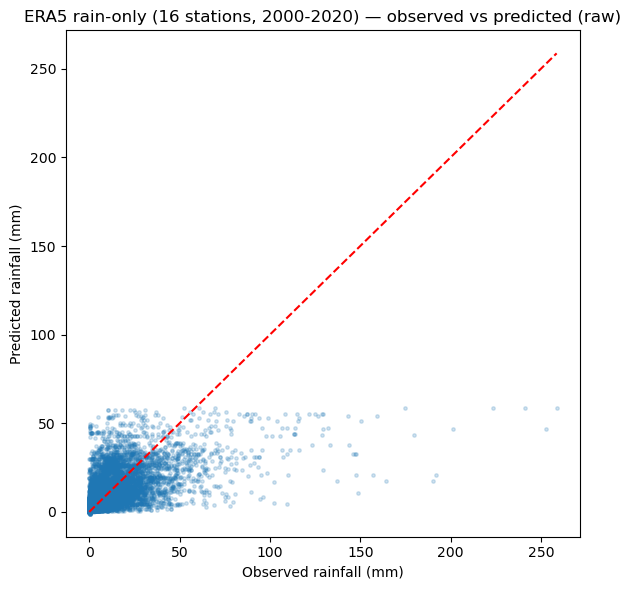

{'RMSE': 10.422215,
 'MAE': 4.949041,
 'Bias': 0.23376171,
 'NRMSE': 1.6132264709204638,
 'tag': 'era5_rain',
 'data': 'ERA5 rain-only (16 stations, 2000-2020)',
 'in_channels': 7,
 'n_stations': 16}

In [15]:
era5_rain_sub = era5_rain.reindex(dates)[selected]
assert era5_rain_sub.isna().sum().sum() == 0, "ERA5 should be gap-free over this window."
run_experiment({'rain': era5_rain_sub}, use_latent=False, tag='era5_rain',
               title='ERA5 rain-only (16 stations, 2000-2020)')

## Run 3 — ERA5 full (12 features, same stations & window)

Adds the 5 auxiliary ERA5 variables (temp, dew, pressure, u10, v10). The gap between Run 2 and Run 3 is the
**feature-richness effect** — what the extra physical variables buy you, holding data source and stations fixed.


ERA5 full 12-feature (16 stations, 2000-2020)  [tag=era5_full, use_latent=True]
feature_order: ['rain', 'temp', 'dew', 'pressure', 'u10', 'v10'] | X: (7671, 16, 12) | in_channels = 12
windows train/val/test: 5362 1144 1144
2026-05-29 18:38:44 | INFO | Starting GCN+GRU training
2026-05-29 18:38:44 | INFO | Device: cuda
2026-05-29 18:38:44 | INFO | Experiment Config:
2026-05-29 18:38:44 | INFO | LR: 0.001
2026-05-29 18:38:44 | INFO | Epochs: 30
2026-05-29 18:38:44 | INFO | Criterion: MSELoss()


Train:   0%|          | 0/168 [00:00<?, ?it/s]

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

2026-05-29 18:38:47 | INFO | Epoch 001 | Train: 0.610327 | Val: 0.687523
2026-05-29 18:38:47 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/era5_full\epoch_1.pt
2026-05-29 18:38:47 | INFO | ✅ New best model saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/era5_full\exp_14_gat_gru_imd_minimap_era5_full_best.pt


Train:   0%|          | 0/168 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

2026-05-29 18:40:03 | INFO | Epoch 030 | Train: 0.287850 | Val: 0.779038
2026-05-29 18:40:03 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_14_gat_gru_imd_minimap/era5_full\epoch_30.pt
2026-05-29 18:40:03 | INFO | Training completed


C:\Users\rishe\AppData\Local\Temp\ipykernel_43164\1685478610.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_state = torch.load(f"{save_dir}/{exp_name}_best.pt", m

Eval:   0%|          | 0/36 [00:00<?, ?it/s]

OVERALL (real): {'NRMSE': 1.552}


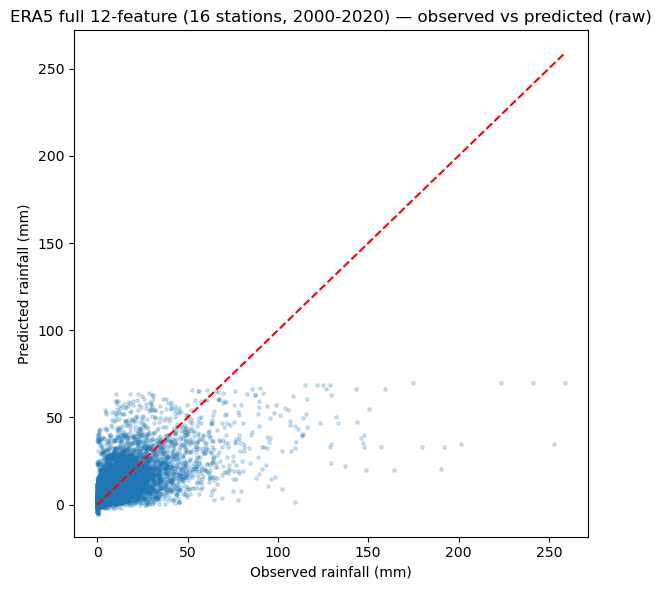

{'RMSE': 10.025347,
 'MAE': 4.599581,
 'Bias': 0.03841187,
 'NRMSE': 1.5517962400884557,
 'tag': 'era5_full',
 'data': 'ERA5 full 12-feature (16 stations, 2000-2020)',
 'in_channels': 12,
 'n_stations': 16}

In [16]:
era5_pivots = load_pivots(ERA5_PIVOT_DIR)            # dict of 6 ERA5 variables
era5_pivots = {k: v.reindex(dates)[selected] for k, v in era5_pivots.items()}
run_experiment(era5_pivots, use_latent=True, tag='era5_full',
               title='ERA5 full 12-feature (16 stations, 2000-2020)')

## Baselines — persistence & climatology (skill floor, real space, IMD test)

If the GAT-GRU on IMD cannot beat **persistence** ("tomorrow = today") or **climatology**
("tomorrow = the train-period average for that day-of-year"), it has learned nothing useful. These are
computed on the exact IMD test targets the model is scored on.

In [17]:
real = imd_win[selected].ffill().bfill().fillna(0)   # real-space rain the model effectively sees
test_real = real.values[v_end:]
y_true    = test_real[SEQ_LEN + HORIZON - 1:]                 # (nwin, N)
y_persist = test_real[SEQ_LEN - 1: -HORIZON]                  # previous observed day

train_real = real.loc[:train_end_date]
clim = train_real.groupby(train_real.index.dayofyear).mean()
clim = clim.reindex(range(1, 367)).ffill().bfill()           # guard leap-day / gaps
test_doy = dates[v_end:][SEQ_LEN + HORIZON - 1:].dayofyear
y_clim = clim.reindex(test_doy).values

for tag, yhat in [('persistence', y_persist), ('climatology', y_clim)]:
    m = _metrics(y_true.reshape(-1), yhat.reshape(-1))
    m.update({'tag': tag, 'data': f'baseline ({tag}) — IMD test', 'in_channels': 0, 'n_stations': len(selected)})
    RESULTS[tag] = m
    print(tag, {k: round(v, 3) for k, v in m.items() if isinstance(v, float)})

pd.DataFrame([RESULTS['persistence'], RESULTS['climatology']]).to_csv(f"{result_path}/baseline_metrics.csv", index=False)

persistence {'RMSE': 22.531, 'MAE': 8.324, 'Bias': -0.0, 'NRMSE': 3.478}
climatology {'RMSE': 18.497, 'MAE': 7.901, 'Bias': -0.179, 'NRMSE': 2.855}


## Comparison table

All real-space test metrics in one place. Read it as:
**baselines (floor) → IMD rain → ERA5 rain (data-source effect) → ERA5 full (feature effect).**

In [18]:
order = ['persistence', 'climatology', 'imd_rain', 'era5_rain', 'era5_full']
comp = pd.DataFrame([RESULTS[t] for t in order if t in RESULTS])
comp = comp[['tag', 'data', 'n_stations', 'in_channels', 'RMSE', 'MAE', 'Bias', 'NRMSE']]
comp.to_csv(f"{result_path}/comparison_table.csv", index=False)
display(comp.round(3))

print("\nInterpretation hooks:")
if {'imd_rain','era5_rain'} <= RESULTS.keys():
    d = RESULTS['imd_rain']['RMSE'] - RESULTS['era5_rain']['RMSE']
    print(f"  data-source gap (IMD - ERA5, rain-only): {d:+.3f} mm RMSE")
if {'era5_rain','era5_full'} <= RESULTS.keys():
    d = RESULTS['era5_rain']['RMSE'] - RESULTS['era5_full']['RMSE']
    print(f"  feature-richness gain (ERA5 rain -> full): {d:+.3f} mm RMSE")
if {'imd_rain','climatology'} <= RESULTS.keys():
    print(f"  IMD model beats climatology: {RESULTS['imd_rain']['RMSE'] < RESULTS['climatology']['RMSE']}")

,tag,data,n_stations,in_channels,RMSE,MAE,Bias,NRMSE
0,persistence,baseline (persistence) — IMD test,16,0,22.531,8.324,-0.000,3.478
1,climatology,baseline (climatology) — IMD test,16,0,18.497,7.901,-0.179,2.855
2,imd_rain,"IMD rain-only (16 stations, 2000-2020)",16,7,17.601,7.672,-0.000,2.717
3,era5_rain,"ERA5 rain-only (16 stations, 2000-2020)",16,7,10.422,4.949,0.234,1.613
4,era5_full,"ERA5 full 12-feature (16 stations, 2000-2020)",16,12,10.025,4.600,0.038,1.552



Interpretation hooks:
  data-source gap (IMD - ERA5, rain-only): +7.179 mm RMSE
  feature-richness gain (ERA5 rain -> full): +0.397 mm RMSE
  IMD model beats climatology: True


## Summary (fill in after running)

- **Headline:** IMD rain-only RMSE = ___, vs ERA5 rain-only (same stations) = ___ → data-source gap = ___ mm.
- **Feature effect:** ERA5 12-feature = ___ (vs ERA5 rain-only).
- **Skill check:** does IMD beat climatology (___)? persistence (___)?
- **Overfitting:** compare train vs val loss in `experiments/logs/{EXP_ID}/imd_rain/...log`; report best-val epoch.

**Handover actions** (do after numbers land — these edit shared files, so confirm first):
- Add row #14 to `plan.md` master comparison table (use `imd_rain` numbers; note matched ERA5 rows too).
- Update `status.md` Research Depth Map: add `exp_14` at L3.
- Append change-log + handover session note (mention window-first deviation from the README's 1970+ plan).